In [20]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [21]:
def plot_relational_plot(df):
    for col in ['Route_Length_km', 'Delay_Minutes']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    company_avgs = df.groupby('Company')[['Route_Length_km', 'Delay_Minutes']].mean().reset_index()
    fig, ax = plt.subplots(figsize=(9, 6))
    plt.plot(company_avgs['Company'], company_avgs['Route_Length_km'], marker='o', label='Avg Route Length [km]', color='royalblue')
    plt.plot(company_avgs['Company'], company_avgs['Delay_Minutes'], marker='s', label='Avg Delay [min]', color='orange')
    plt.title('Average Route Length and Delay by Company')
    plt.xlabel('Company')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    plt.savefig('relational_plot.png')
    return

In [22]:
def plot_categorical_plot(df):
    df['Cost_kUSD'] = pd.to_numeric(df['Cost_kUSD'], errors='coerce')
    avg_cost = df.groupby('Company')['Cost_kUSD'].mean().reset_index()
    fig, ax = plt.subplots(figsize=(8,6))
    plt.bar(avg_cost['Company'], avg_cost['Cost_kUSD'], color='teal')
    plt.title('Average Shipping Cost by Company')
    plt.xlabel('Company')
    plt.ylabel('Average Cost [thousands USD]')
    plt.tight_layout()
    plt.show()
    plt.savefig('categorical_plot.png')
    return

In [23]:
def plot_statistical_plot(df):
    num_cols = ['Shipments', 'Avg_Weight_Tons', 'Route_Length_km', 'Delay_Minutes', 'Cost_kUSD']
    for col in num_cols:
      df[col] = pd.to_numeric(df[col], errors='coerce')

    corr = df[num_cols].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(corr,mask=mask,annot=True,cmap='coolwarm',vmin=-1, vmax=1,square=True,linewidths=0.8,cbar_kws={'shrink': .8})
    plt.title('Correlation Heatmap (Lower Triangular)')
    plt.tight_layout()
    plt.show()
    plt.savefig('statistical_plot.png')
    return

In [24]:
def statistical_analysis(df, col: str):
    mean = df[col].mean()
    stddev = df[col].std()
    skew = df[col].skew()
    excess_kurtosis = df[col].kurtosis()
    return mean, stddev, skew, excess_kurtosis

In [25]:
def preprocessing(df):
    # You should preprocess your data in this function and
    df['Cost_kUSD'] = pd.to_numeric(df['Cost_kUSD'], errors='coerce')
    avg_cost = df.groupby('Company')['Cost_kUSD'].mean().reset_index()
    for col in ['Route_Length_km', 'Delay_Minutes']:
      df[col] = pd.to_numeric(df[col], errors='coerce')
    company_avgs = df.groupby('Company')[['Route_Length_km', 'Delay_Minutes']].mean().reset_index()
    # make use of quick features such as 'describe', 'head/tail' and 'corr'.

    # Display the first few rows
    print("DataFrame Head:")
    display(df.head())

    # Display the last few rows
    print("\nDataFrame Tail:")
    display(df.tail())

    # Display descriptive statistics
    print("\nDataFrame Description:")
    display(df.describe())

    # Display the correlation matrix for numerical columns
    print("\nDataFrame Correlation Matrix:")
    display(df.corr(numeric_only=True))

    return df, company_avgs, avg_cost

In [26]:
def writing(moments, col):
    print(f'For the attribute {col}:')
    print(f'Mean = {moments[0]:.2f}, '
          f'Standard Deviation = {moments[1]:.2f}, '
          f'Skewness = {moments[2]:.2f}, and '
          f'Excess Kurtosis = {moments[3]:.2f}.')

    # Interpret Skewness
    skewness = moments[2]
    if skewness > 0.5:
        skew_interpretation = "right skewed (positively skewed)"
    elif skewness < -0.5:
        skew_interpretation = "left skewed (negatively skewed)"
    else:
        skew_interpretation = "approximately symmetric (not skewed)"

    # Interpret Kurtosis (Excess Kurtosis)
    excess_kurtosis = moments[3]
    if excess_kurtosis > 0:
        kurtosis_interpretation = "leptokurtic (heavier tails than a normal distribution)"
    elif excess_kurtosis < 0:
        kurtosis_interpretation = "platykurtic (lighter tails than a normal distribution)"
    else:
        kurtosis_interpretation = "mesokurtic (similar to a normal distribution)"

    print(f'The data is {skew_interpretation} and is {kurtosis_interpretation}.')
    return

In [27]:
def main():
    df = pd.read_csv('data1.csv')
    df, company_avgs, avg_cost = preprocessing(df)
    col = 'Delay_Minutes'
    plot_relational_plot(df)
    plot_statistical_plot(df)
    plot_categorical_plot(df)
    moments = statistical_analysis(df, col)
    writing(moments, col)
    return

DataFrame Head:


,Company,Shipments,Avg_Weight_Tons,Route_Length_km,Delay_Minutes,Cost_kUSD
0,SeaWings,15,11.0,2659.0,53.0,36.4
1,OceanX,32,13.0,2697.0,88.0,92.0
2,CargoJet,17,20.2,508.0,12.0,14.3
3,BlueStream,40,15.3,1908.0,60.0,94.9
4,SwiftCargo,31,19.4,2447.0,92.0,120.0



DataFrame Tail:


,Company,Shipments,Avg_Weight_Tons,Route_Length_km,Delay_Minutes,Cost_kUSD
2,CargoJet,17,20.2,508.0,12.0,14.3
3,BlueStream,40,15.3,1908.0,60.0,94.9
4,SwiftCargo,31,19.4,2447.0,92.0,120.0
5,...,...,...,NaN,NaN,NaN
6,SwiftCargo,15,11.3,1219.0,15.0,16.9



DataFrame Description:


,Route_Length_km,Delay_Minutes,Cost_kUSD
count,6.000000,6.000000,6.000000
mean,1906.333333,53.333333,62.416667
std,884.505210,34.407364,45.409313
min,508.000000,12.000000,14.300000
25%,1391.250000,24.500000,21.775000
50%,2177.500000,56.500000,64.200000
75%,2606.000000,81.000000,94.175000
max,2697.000000,92.000000,120.000000



DataFrame Correlation Matrix:


,Route_Length_km,Delay_Minutes,Cost_kUSD
Route_Length_km,1.000000,0.868920,0.665083
Delay_Minutes,0.868920,1.000000,0.923054
Cost_kUSD,0.665083,0.923054,1.000000


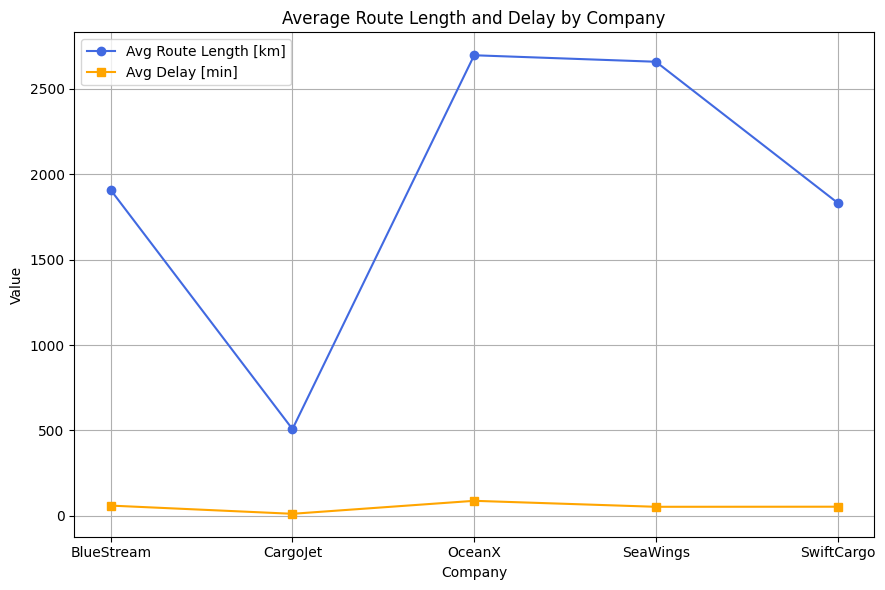

<Figure size 640x480 with 0 Axes>

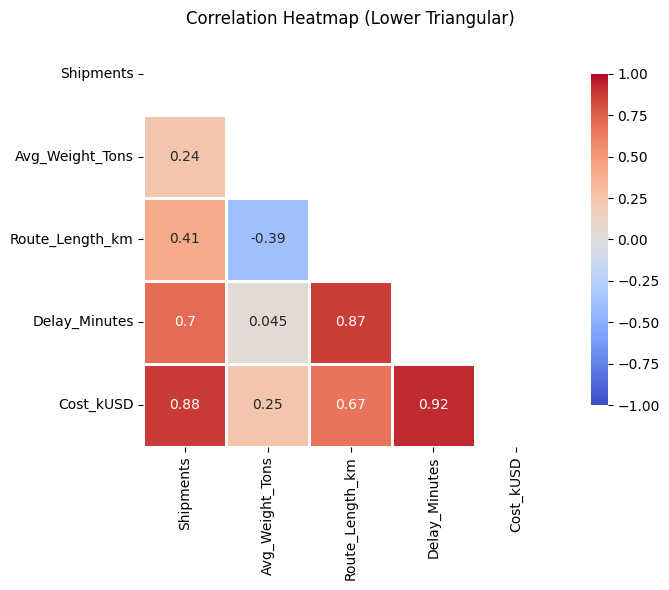

<Figure size 640x480 with 0 Axes>

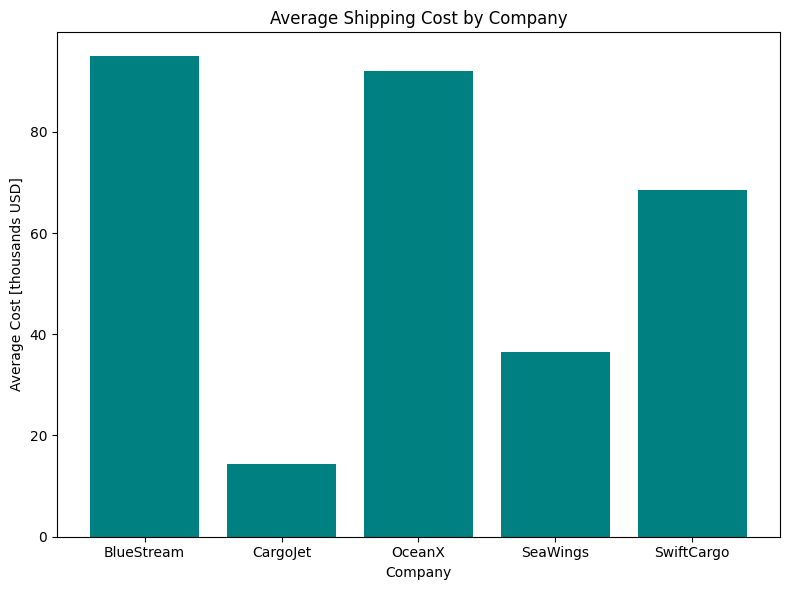

For the attribute Delay_Minutes:
Mean = 53.33, Standard Deviation = 34.41, Skewness = -0.20, and Excess Kurtosis = -1.87.
The data is approximately symmetric (not skewed) and is platykurtic (lighter tails than a normal distribution).


<Figure size 640x480 with 0 Axes>

In [28]:
if __name__ == '__main__':
    main()